<a href="https://colab.research.google.com/github/ayushpaliwal1920/Deep_Learning/blob/main/21_BatchNormalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_classification
import pandas as pd

# generate data
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    flip_y=0.1,   # 10% labels randomly flipped / noise
    random_state=42,
    n_clusters_per_class=1,

)

# convert to DataFrame
df = pd.DataFrame(X, columns=['X', 'Y'])
df['class'] = y

print(df.head())

          X         Y  class
0  2.502258  2.548817      1
1 -0.676214  1.412767      0
2 -1.310385  0.556563      0
3  2.075149  2.209383      1
4  0.974777  1.045987      1


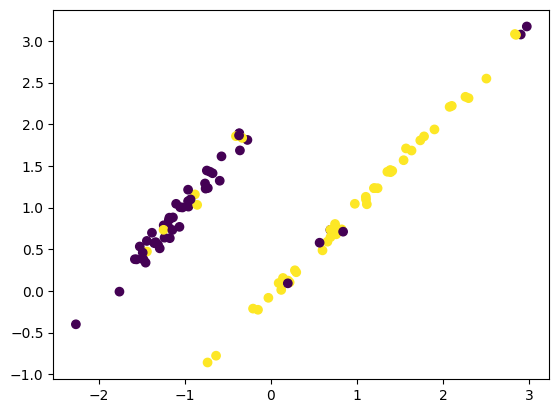

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])


In [15]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,BatchNormalization

In [16]:
model1 = Sequential()

# simple model :


model1.add(Dense(3,activation='relu',input_dim=2))
model1.add(Dense(2,activation='relu'))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
model1.compile(loss="binary_crossentropy",optimizer = "adam",metrics = ['accuracy'])

In [18]:
history = model1.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.1500 - loss: 0.7475 - val_accuracy: 0.2500 - val_loss: 0.7534
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1500 - loss: 0.7446 - val_accuracy: 0.2500 - val_loss: 0.7507
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1500 - loss: 0.7422 - val_accuracy: 0.2500 - val_loss: 0.7480
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1500 - loss: 0.7396 - val_accuracy: 0.2500 - val_loss: 0.7454
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1500 - loss: 0.7372 - val_accuracy: 0.2500 - val_loss: 0.7429
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1375 - loss: 0.7348 - val_accuracy: 0.2500 - val_loss: 0.7404
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1375 - loss: 0.7324 - val_accuracy: 0.2500 - val_loss: 0.7380
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1375 - loss: 0.7300 - val_accuracy: 0.2500 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


<Axes: >

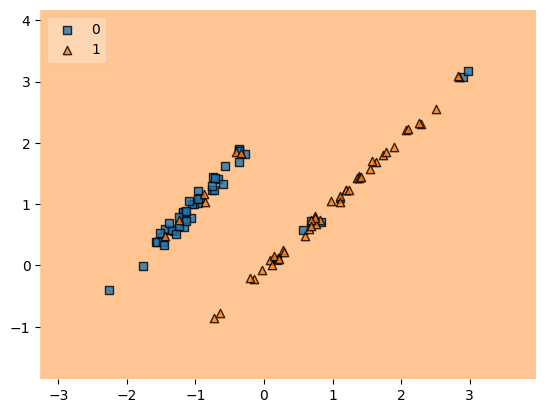

In [19]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X=X,
                      y=y.astype(int),
                      clf=model1,
                      legend=2)

# Batch Normalization :

In [20]:
model = Sequential()

# simple model :

model.add(Dense(3,activation='relu',input_dim =2))
model.add(BatchNormalization())
model.add(Dense(2,activation='relu'))
model.add(BatchNormalization())

model.add(Dense(1,activation="sigmoid"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [21]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])


In [22]:
history2 = model.fit(X,y,epochs=200,validation_split=0.2)


Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.2375 - loss: 0.9083 - val_accuracy: 0.2000 - val_loss: 0.7130
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2500 - loss: 0.8788 - val_accuracy: 0.2000 - val_loss: 0.7127
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2250 - loss: 0.8770 - val_accuracy: 0.2000 - val_loss: 0.7124
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2375 - loss: 0.8766 - val_accuracy: 0.2000 - val_loss: 0.7121
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2250 - loss: 0.8943 - val_accuracy: 0.2000 - val_loss: 0.7116
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2375 - loss: 0.8850 - val_accuracy: 0.2500 - val_loss: 0.7112
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2375 - loss: 0.8800 - val_accuracy: 0.2500 - val_loss: 0.7107
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2500 - loss: 0.8471 - val_accuracy: 0.2500 - val_loss

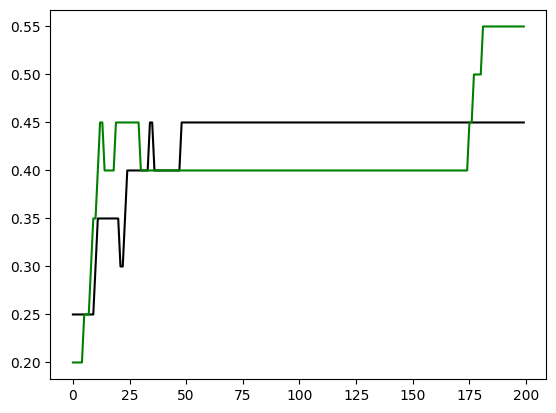

In [24]:
plt.plot(history.history['val_accuracy'],color='black')
plt.plot(history2.history['val_accuracy'],color='green')

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

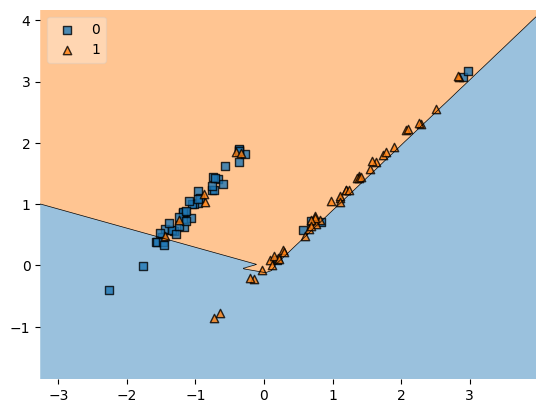

In [25]:

plot_decision_regions(X=X,
                      y=y.astype(int),
                      clf=model,
                      legend=2)